<a href="https://colab.research.google.com/github/vrinda0115/PRODIGY_ML_04/blob/main/task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import numpy as np
import pandas as pd

# Load dataset (Sign Language MNIST CSV format)
train_data = pd.read_csv('sign_mnist_train.csv')
test_data = pd.read_csv('sign_mnist_test.csv')

# Separate labels and features
y_train = train_data['label']
X_train = train_data.drop('label', axis=1)
y_test = test_data['label']
X_test = test_data.drop('label', axis=1)

# Normalize and reshape
X_train = X_train.values.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.values.reshape(-1, 28, 28, 1) / 255.0

# One-hot encode labels
lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)


In [3]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(24, activation='softmax')  # 24 for A-Y (J excluded)
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.5433 - loss: 1.5629 - val_accuracy: 0.8793 - val_loss: 0.3997
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.9947 - loss: 0.0405 - val_accuracy: 0.8997 - val_loss: 0.3806
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9062 - val_loss: 0.3832
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9821 - loss: 0.0591 - val_accuracy: 0.9232 - val_loss: 0.3613
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 1.0000 - loss: 6.0819e-04 - val_accuracy: 0.9225 - val_loss: 0.3767
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.8674 - val_loss: 0.5681
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.9970 - loss: 0.0130 - val_accuracy: 0.9186 - val_loss: 0.3913
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 1.0000 - loss: 2.227

In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9184 - loss: 0.4278
Test Accuracy: 92.04%


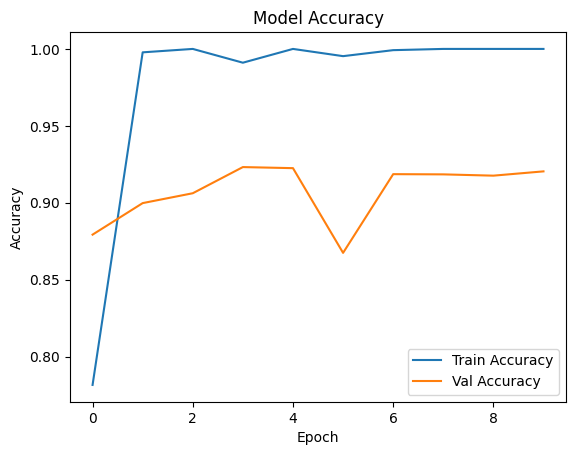

In [6]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()



In [8]:
model.save("gesture_model.keras")


In [9]:
model = tf.keras.models.load_model("gesture_model.keras")
lb = joblib.load("label_encoder.pkl")


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
def preprocess_external_image(image_path):
    img = Image.open(image_path).convert('L')  # Grayscale
    img = img.resize((28, 28))  # Resize
    img = np.array(img) / 255.0  # Normalize
    img = img.reshape(1, 28, 28, 1)
    return img


In [11]:
def predict_gesture(image_path):
    if not os.path.exists(image_path):
        print("Image not found.")
        return
    img = preprocess_external_image(image_path)
    prediction = model.predict(img)
    predicted_index = np.argmax(prediction)

    one_hot = np.zeros((1, 24))
    one_hot[0, predicted_index] = 1
    predicted_label = lb.inverse_transform(one_hot)[0]

    print(f"Predicted Hand Gesture: {chr(predicted_label + 65)}")


In [24]:
#Test with Uploaded Image
predict_gesture("/content/t_s_lang.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Hand Gesture: T
